# Human Activity Recognition with Wifi

In [1]:
import numpy as np
import numpy.random as rnd
import torch
import matplotlib.pyplot as plt

from models.DopplerDataset import * 
from models.SHARP import *
from utilities.training import *
from utilities.plotting import *

from time import time 
from torchvision.transforms import Compose, ToTensor, RandomHorizontalFlip, RandomVerticalFlip
from torch.utils.data import DataLoader
from os import listdir, makedirs, path
from tqdm import tqdm

%load_ext autoreload
%autoreload 2


###############  GLOBAL VARIABLES  #################
DEBUG_MODE                 = True

PERFORM_DATASET_SEPARATION = True
DATASET_PATH               = "doppler_traces"
TEST_DATASET_FRACTION      = 0.1
DOPPLER_TRACE_SIZE         = 340

## Separating training dataset and test dataset

In [2]:
'''
    We split each Doppler trace in DATASET_PATH into several Doppler sub-traces of size DOPPLER_TRACE_SIZE,
    then we randomly split each collection of sub-traces into a train/test dataset folder.
'''

train_dataset = DATASET_PATH + "_train"
test_dataset  = DATASET_PATH + "_test"
if PERFORM_DATASET_SEPARATION and (train_dataset not in listdir()) and (test_dataset not in listdir()):
    subdir_list = sorted([name for name in listdir(DATASET_PATH) if path.isdir(DATASET_PATH+'/'+name)])

    # Counting number of images in DATASET_PATH
    traces_number = 0
    for subdir in subdir_list:
        traces_number += len(listdir(DATASET_PATH+'/'+subdir))
    print(f"Dataset {DATASET_PATH} contains {traces_number} traces.\nProceding to create training dataset with {int((1-TEST_DATASET_FRACTION)*traces_number)} traces and test dataset with {int(TEST_DATASET_FRACTION*traces_number)} traces...\n")

    # Creating train and test datasets
    makedirs(train_dataset, exist_ok=True)
    makedirs(test_dataset, exist_ok=True)

    # Creating a index array to split traces into different datasets
    index = np.arange(0, traces_number)
    rnd.shuffle(index)
    test_index  = index[:int(traces_number*TEST_DATASET_FRACTION)]

    # Splitting a trace in many sub-traces and randomly assigning them to train/test dataset
    idx = 0
    for subdir in subdir_list:
        for trace_name in sorted(listdir(DATASET_PATH+'/'+subdir)):
            trace_path = DATASET_PATH+'/'+subdir+'/'+trace_name
            full_trace = np.load(trace_path, allow_pickle=True)
            N_images = full_trace.shape[0]//DOPPLER_TRACE_SIZE

            for i in range(N_images):
                # Name of sub-trace is the one the original full trace + an index to distinguish
                if idx in test_index:
                    np.save(test_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
                else:
                    np.save(train_dataset+'/'+trace_name[:-4]+f"-{i}", full_trace[i*DOPPLER_TRACE_SIZE:(i+1)*DOPPLER_TRACE_SIZE, :], allow_pickle=True)
            
            # All sub-traces of the same file are assigned to the same dataset
            idx += 1

    print("Train and test datasets created successfully!")
else:
    print("Datasets are already splitted!")

Datasets are already splitted!


## Loading Dataset

In [3]:
transforms = Compose([
    RandomVerticalFlip(),
    RandomHorizontalFlip()
])

Loading dataset doppler_traces_train in memory...


18680it [00:10, 1855.77it/s]


Dataset is loaded!
Loading dataset doppler_traces_test in memory...


6577it [00:03, 2096.91it/s]


Dataset is loaded!


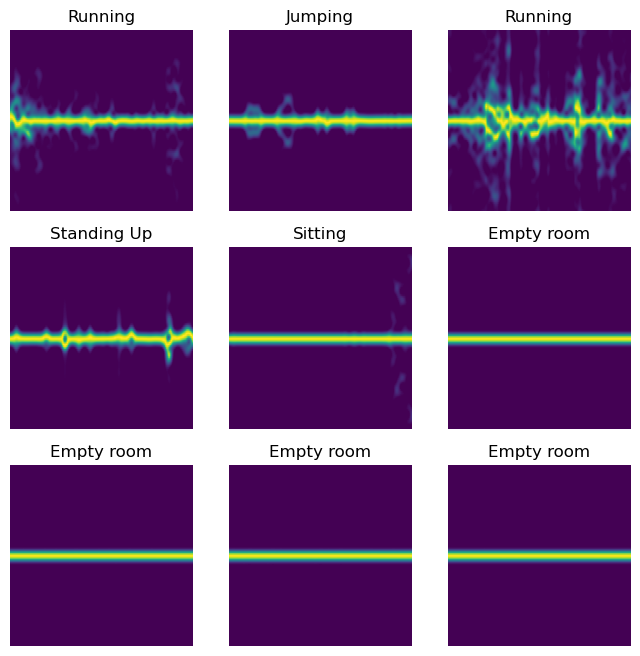

In [4]:
batch_size = 128
train_dataset  = DopplerDataset("doppler_traces_train")
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

test_dataset  = DopplerDataset("doppler_traces_test")
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

labels_map = {
    0: "Standing",
    1: "Walking",
    2: "Running",
    3: "Standing Up",
    4: "Empty room",
    5: "Sitting",
    6: "Moving arm",
    7: "Jumping"
}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols*rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[int(label)])
    plt.axis("off")
    plt.imshow(img[0,:,:], aspect='auto')
plt.show()

## Training of SHARP architecure

In [5]:
learning_rate = 1e-4
epochs = 10

sharp_model = SHARP()

device    = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=sharp_model.parameters(), lr=learning_rate)

if DEBUG_MODE:
    #### CHECKING DATA TYPES 
    x, y = next(iter(train_dataloader))
    print(x.dtype)
    print(next(sharp_model.parameters()).dtype)
    ### DEVICE
    print(f"Device: {device}")

torch.float32
torch.float32
Device: mps


In [6]:
epochs = 10
train_loss, test_loss, _ = train_model(sharp_model, train_dataloader, test_dataloader, epochs, loss_fn, optimizer, device, verbosity=True)

Starting model training...
Completed epochs: 0/10
loss: 1.00000e+10  [    0/18680]
loss: 2.03375e+00  [ 1280/18680]
loss: 2.01183e+00  [ 2560/18680]
loss: 2.04180e+00  [ 3840/18680]
loss: 2.05046e+00  [ 5120/18680]
loss: 2.02559e+00  [ 6400/18680]
loss: 2.01865e+00  [ 7680/18680]
loss: 2.02766e+00  [ 8960/18680]
loss: 2.00117e+00  [10240/18680]
loss: 1.98070e+00  [11520/18680]
loss: 2.02470e+00  [12800/18680]
loss: 1.94492e+00  [14080/18680]
loss: 1.97938e+00  [15360/18680]
loss: 2.05689e+00  [16640/18680]
loss: 1.99113e+00  [17920/18680]
Test Error: 
 Accuracy: 20.6%, Avg loss: 2.004598 

Completed epochs: 1/10 ------ Time (total): 14.00 ------ Time (relative): 14.00

loss: 1.00000e+10  [    0/18680]
loss: 1.98857e+00  [ 1280/18680]
loss: 1.99244e+00  [ 2560/18680]
loss: 1.98532e+00  [ 3840/18680]
loss: 1.91010e+00  [ 5120/18680]
loss: 1.94997e+00  [ 6400/18680]
loss: 1.90698e+00  [ 7680/18680]
loss: 1.94354e+00  [ 8960/18680]
loss: 1.96578e+00  [10240/18680]
loss: 1.91115e+00  [11520

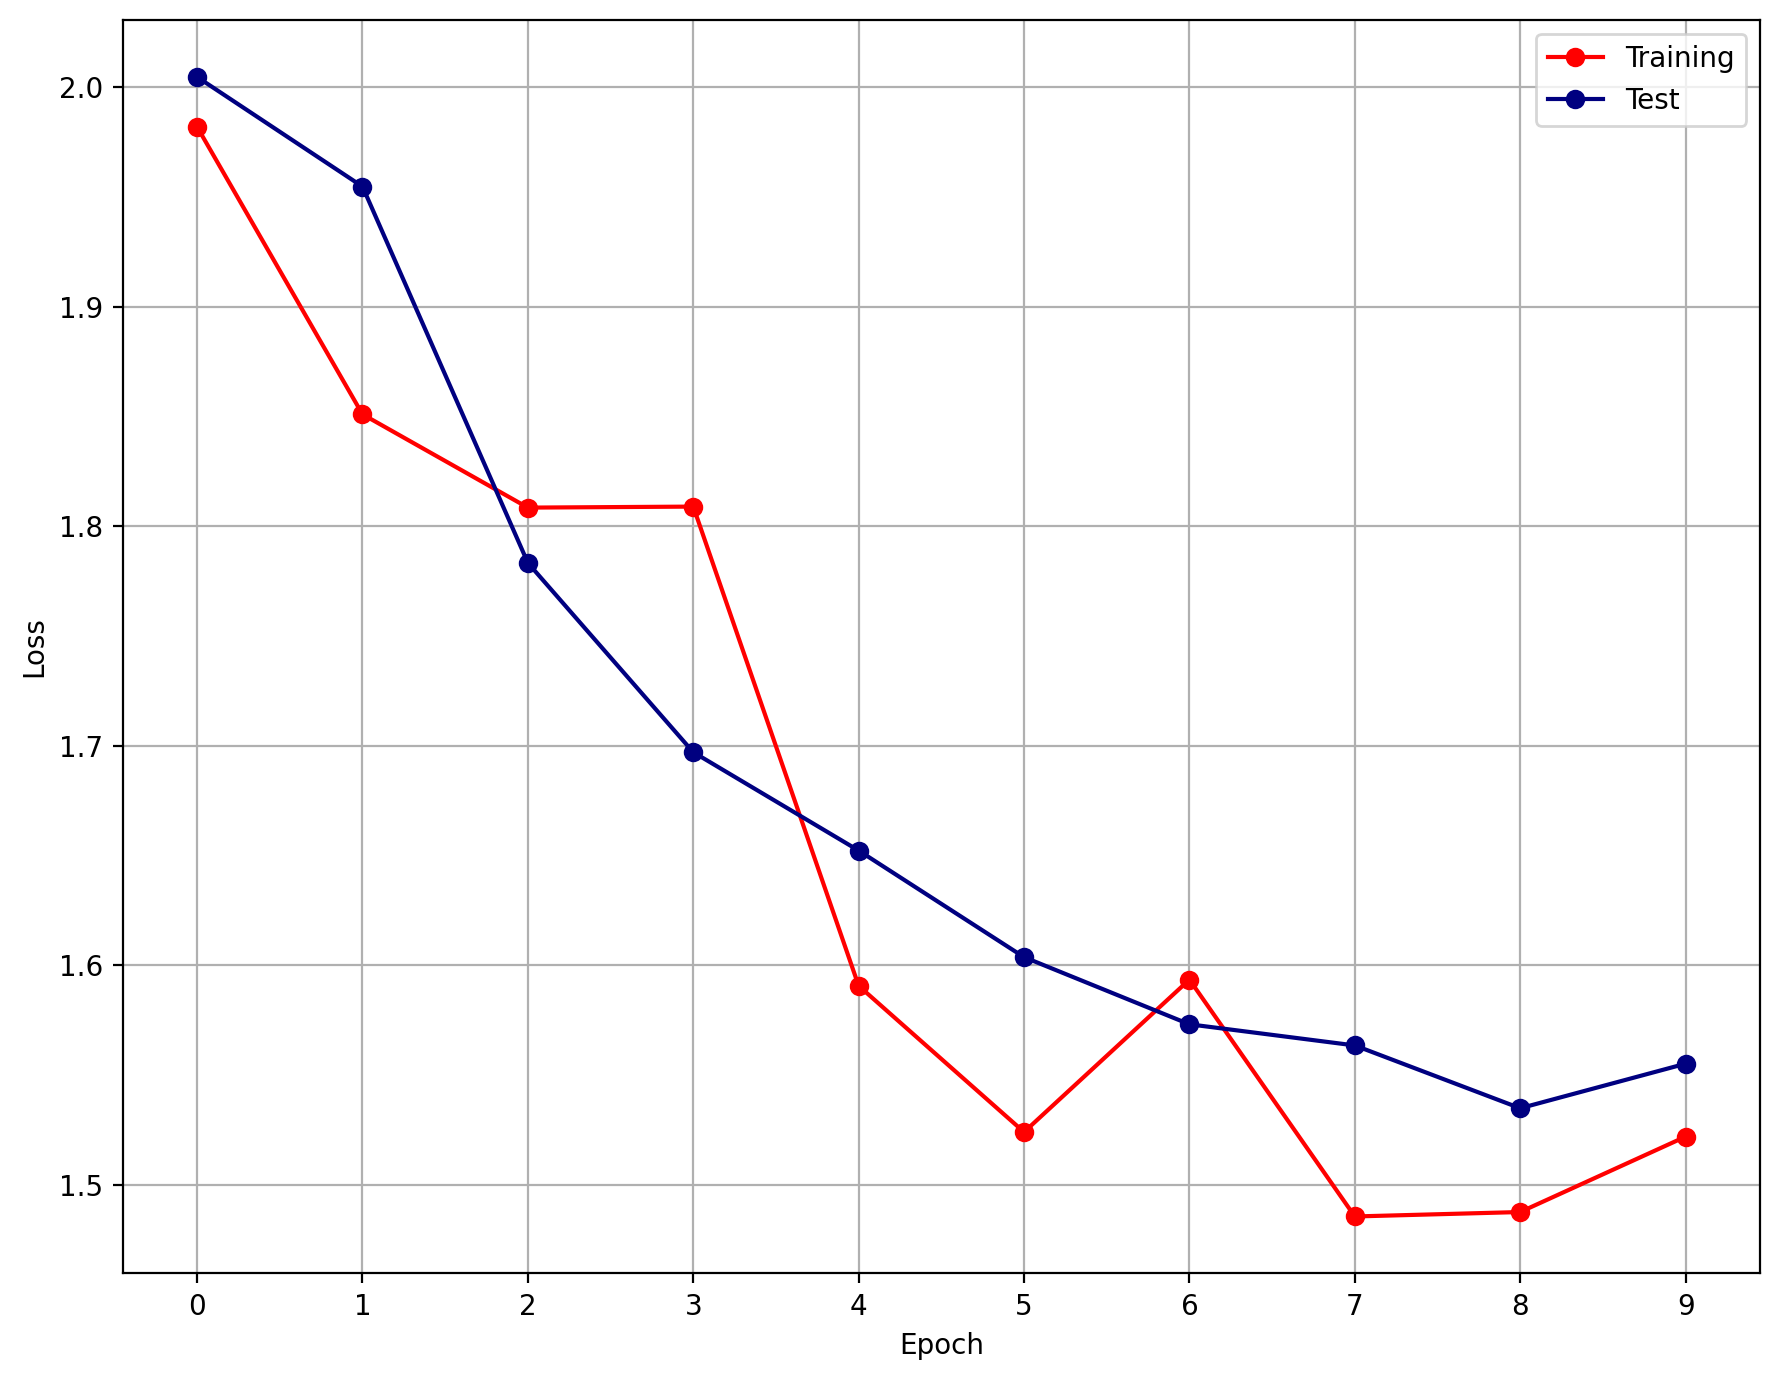

In [8]:
plot_loss(train_loss, test_loss)